In [1]:
# Menginstal library yang dibutuhkan
!pip install transformers torch
!pip install bertopic sentence-transformers
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.6 MB/s eta 0:00:00


In [2]:
# Mengimpor library yang dibutuhkan
import pandas as pd
import re
import torch
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk

In [3]:
# Menghubungkan Colab dengan Google Drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


### Data Preparation

*Data Gunung Ciremai*

In [ ]:
base_path = '/content/drive/MyDrive/Projek/dummy/gunung_jabar/raw/'

In [ ]:
mountain_info = {
    'ciremai': 'gunung ciremai',
    'cikuray': 'gunung cikuray',
    'papandayan': 'gunung papandayan',
    'salak': 'gunung salak',
    'gede_pangrango': 'gunung gede pangrango'
}

In [ ]:
dfs = {}

for file_key, mountain_name in mountain_info.items():
    # Buat nama file lengkap secara dinamis
    file_name = f'review_gn_{file_key}_raw.csv'
    file_path = base_path + file_name

    try:
        # Muat CSV
        df = pd.read_csv(file_path)

        # Tambahkan kolom 'nama_gunung' (sama seperti .insert() Anda)
        df['nama_gunung'] = mountain_name

        # Mengubah urutan kolom
        cols = ['nama_gunung'] + [col for col in df.columns if col != 'nama_gunung']
        df = df[cols]

        # Simpan DataFrame ke dalam dictionary 'dfs'
        dfs[file_key] = df

        print(f"Berhasil memuat dan memberi tag: {file_name}")

    except FileNotFoundError:
        print(f"ERROR: File tidak ditemukan di {file_path}")
    except Exception as e:
        print(f"ERROR saat memproses {file_name}: {e}")

Berhasil memuat dan memberi tag: review_gn_ciremai_raw.csv
Berhasil memuat dan memberi tag: review_gn_cikuray_raw.csv
Berhasil memuat dan memberi tag: review_gn_papandayan_raw.csv
Berhasil memuat dan memberi tag: review_gn_salak_raw.csv
Berhasil memuat dan memberi tag: review_gn_gede_pangrango_raw.csv


In [ ]:
df_merged = pd.concat(dfs.values(), ignore_index=True)

In [ ]:
columns = [
    'reviewId',
    'nama_gunung',
    'text',
    'stars',
    'name'
]

In [ ]:
df_gunung_jabar = df_merged[columns]

In [ ]:
df_gunung_jabar['nama_gunung'].value_counts()

,count
nama_gunung,
gunung gede pangrango,8333
gunung papandayan,7780
gunung ciremai,5855
gunung cikuray,3118
gunung salak,2403


In [ ]:
df_gunung_jabar.head()

,reviewId,nama_gunung,text,stars,name
0,Ci9DQUlRQUNvZENodHljRjlvT2poNVVrWkhaRTVrVkVwZl...,gunung ciremai,14/10/2025 12.00 puncak ciremai.\nterimakasih ...,5,maesa putri
1,Ci9DQUlRQUNvZENodHljRjlvT214a2NsOXpYMGhPWWxwQl...,gunung ciremai,Wahh bagus bet sih pemandangan nya tapi cape p...,5,Andika Febri
2,Ci9DQUlRQUNvZENodHljRjlvT2paTU5tNVVVMTlWV2xsaU...,gunung ciremai,"Tempat yang sejuk, damai dan dipenuhi dengan k...",5,Teguh Wahyudi
3,Ci9DQUlRQUNvZENodHljRjlvT21WaGNtSjJRVFpDTUhsNE...,gunung ciremai,NaN,5,Husor Parlindungan
4,Ci9DQUlRQUNvZENodHljRjlvT21kRWJEVllSRkpIU25CaU...,gunung ciremai,NaN,5,Tegar Putra Ramdhani


In [ ]:
# Menyimpan DataFrame gabungan ke file CSV
df_gunung_jabar.to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/raw/review_gunung_jabar_raw.csv', index=False)

### Data Cleaning

In [ ]:
# Membaca kembali data gabungan dari file CSV untuk proses cleaning
df_gn_jabar = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/raw/review_gunung_jabar_raw.csv')

In [ ]:
# Menampilkan informasi DataFrame (jumlah non-null, tipe data, dll.)
df_gn_jabar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27489 entries, 0 to 27488
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   reviewId     27489 non-null  object
 1   nama_gunung  27489 non-null  object
 2   text         14570 non-null  object
 3   stars        27489 non-null  int64 
 4   name         27489 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.0+ MB


In [ ]:
# Menghitung jumlah nilai yang hilang (NaN) di setiap kolom
df_gn_jabar.isna().sum(axis=0)

,0
reviewId,0
nama_gunung,0
text,12919
stars,0
name,0


In [ ]:
# Menghapus baris dengan nilai yang hilang di kolom 'text'
df_gn_jabar = df_gn_jabar.dropna(subset=['text'])

In [ ]:
# Menghapus baris dengan panjang teks kurang dari atau sama dengan 15
df_gn_jabar = df_gn_jabar[df_gn_jabar['text'].str.len() > 15]

In [ ]:
# Menghitung jumlah duplikat berdasarkan reviewId
df_gn_jabar['reviewId'].duplicated().sum()

np.int64(345)

In [ ]:
# Menghapus duplikat berdasarkan reviewId
df_gn_jabar = df_gn_jabar.drop_duplicates(subset=['reviewId'])

In [ ]:
# Fungsi untuk membersihkan teks

def clean_text(text: str) -> str:
    # Lowercase
    text = text.lower()

    # Hapus URL
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # Hapus mention (@username) dan hashtag (#tag)
    text = re.sub(r'@\w+|#\w+', '', text)

    # Hapus mention (@username) dan hashtag (#topic)
    text = re.sub(r'@[A-Za-z0-9_]+|#[A-Za-z0-9_]+', '', text)

    # Hapus emoji dan karakter non-alfabet (sisakan huruf dan spasi)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Gabungkan partikel terpisah (contoh: 'service nya' → 'servicenya')
    text = re.sub(r'\b(\w+)\s+(nya|ku|mu)\b', r'\1\2', text)

    # Hapus ekstra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Hapus angka
    text = re.sub(r'\d+', '', text)

    # Normalisasi tanda baca berulang (misal ..., !!!, ???)
    text = re.sub(r'([!?.,])\1{1,}', r'\1', text)

    # Normalisasi huruf berulang (contoh: peliittt → pelit)
    text = re.sub(r'(.)\1{1,}', r'\1', text)

    return text

# Menerapkan fungsi cleaning pada kolom 'text'
df_gn_jabar['text'] = df_gn_jabar['text'].apply(clean_text)

In [ ]:
# Kamus untuk normalisasi slang kata
normalize_dict = {
    "aj": "saja",
     "aja": "saja",
     "aje": "saja",
     "akamsi": "anak kampung sini",
     "amat" : "sangat",
     "amp": "dan",
     "bhkan": "bahkan",
     "bakal": "akan",
     "bener": "benar",
     "ben": "biar",
     "bbrp" : "beberapa",
     "brp" : "berapa",
     "bgn": "bangun",
     "biar": "agar",
     "bisaa": "bisa",
     "bgt": "banget",
     "bet": "banget",
     "bikin": "membuat",
     "blm": "belum",
     "byk": "banyak",
     "bodoh": "bodoh",
     "cuma": "hanya",
     "cetek": "dangkal",
     "dah": "udah",
     "dengernye" : "dengarnya",
     "didenger" : "didengar",
     "dengerinnya": "mendengarkannya",
     "dg": "dengan",
     "dgn": "dengan",
     "dl": "dulu",
     "diriin" : "mendirikan",
     "dikasi" : "diberi",
     "doang": "saja",
     "dong": "lah",
     "dr": "dari",
     "dri": "dari",
     "dikira": "mengira",
     "duid" : "uang",
     "duit" : "uang",
     "emang": "memang",
     "emg": "memang",
     "enak": "lezat",
     "g": "tidak",
     "ga": "tidak",
     "gak": "tidak",
     "gapapa" : "tidak apa-apa",
     "gpp" : "tidak apa apa",
     "ngadain" : "mengadakan",
     "ngasih" : "memberi",
     "ngelurusin": "meluruskna",
     "nggakpapa" : "tidak apa apa",
     "ngapapa" : "tidak apa apa",
     "nyobain" : "mencoba",
     "gausa": "tidak usah",
     "gausah": "tidak usah",
     "gini": "begini",
     "gitu": "begitu",
     "gk": "tidak",
     "gn" : "gunung",
     "gua": "saya",
     "gue": "saya",
     "gw": "saya",
     "inet": "internet",
     "itung": "hitung",
     "janji": "komitmen",
     "jd": "jadi",
     "jg": "juga",
     "kagak": "tidak",
     "kayak": "seperti",
     "kaya": "seperti",
     "kalo" : "kalau",
     "ketolong" : "tertolong",
     "kl": "kalau",
     "km": "kamu",
     "klo": "kalau",
     "knp": "kenapa",
     "kpd": "kepada",
     "krn": "karena",
     "kutau": "aku tahu",
     "lgsung": "langsung",
     "lsg": "langsung",
     "liat": "lihat",
     "lu": "kamu",
     "mah": "memang",
     "maksa": "memaksa",
     "mau": "ingin",
     "mgga": "tidak",
     "minta": "meminta",
     "mluruskan": "meluruskna",
     "mo" : "ingin",
     "naek": "naik",
     "nnti": "nanti",
     "ndengerinnya": "mendengarkannya",
     "ngeluh": "mengeluh",
     "ngepoin": "mengamati",
     "ngerti": "mengerti",
     "ngga": "tidak",
     "nggak": "tidak",
     "nggk": "tidak",
     "ngitung": "menghitung",
     "ngimpi": "mimpi",
     "ni": "ini",
     "nih": "ini",
     "nyebut": "menyebut",
     "org": "orang",
     "padalan": "padahal",
     "pake": "pakai",
     "prnah": "pernah",
     "pesen": "pesan",
     "ra": "tidak",
     "rb": "ribu",
     "sbgai": "sebagai",
     "sampe": "sampai",
     "samsek": "sama sekali",
     "sbnrnya": "sebenarnya",
     "sdh": "sudah",
     "sm": "sama",
     "soal": "tentang",
     "surken": "surya kencana",
     "sy": "saya",
     "tdk": "tidak",
     "tolol": "bodoh",
     "tp": "tapi",
     "trus": "terus",
     "trs": "terus",
     "u": "kamu",
     "udh": "sudah",
     "udah": "sudah",
     "utk": "untuk",
     "gue": "saya",
     "gua": "saya",
     "yg": "yang",
     "ye": "iya",
     "rekomen": "rekomendasi" ,
     "view" : "pemandangan" ,
     "viewnya" : "pemandangan"
}

# Fungsi untuk normalisasi slang kata
def normalize_text(text):
    text = str(text).lower()
    tokens = text.split()
    normalized_tokens = [normalize_dict.get(token, token) for token in tokens]
    return ' '.join(normalized_tokens)

df_gn_jabar['text'] = df_gn_jabar['text'].apply(normalize_text)

In [ ]:
df_gn_jabar.head()

,reviewId,nama_gunung,text,stars,name
0,Ci9DQUlRQUNvZENodHljRjlvT2poNVVrWkhaRTVrVkVwZl...,gunung ciremai,puncak ciremai terimakasih ciremai sudah mengi...,5,maesa putri
1,Ci9DQUlRQUNvZENodHljRjlvT214a2NsOXpYMGhPWWxwQl...,gunung ciremai,wah bagus banget sih pemandanganya tapi cape p...,5,Andika Febri
2,Ci9DQUlRQUNvZENodHljRjlvT2paTU5tNVVVMTlWV2xsaU...,gunung ciremai,tempat yang sejuk damai dan dipenuhi dengan ke...,5,Teguh Wahyudi
6,Ci9DQUlRQUNvZENodHljRjlvT21OeVltNHpORUY2UjA5V2...,gunung ciremai,ngadem dengan pemandangan yang memukau,5,M. Sofwan
8,Ci9DQUlRQUNvZENodHljRjlvT25oSmVtMWhPR3hRUjBSUk...,gunung ciremai,entah kenapa pendakian ciremai ini berbeda sea...,5,Eddielawan Ginting


In [ ]:
# Menyimpan DataFrame yang sudah dibersihkan ke file CSV
df_gn_jabar.to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/cleaned/review_gunung_jabar_cleaned.csv', index=False)

### Modeling IndoBERT for Sentiment Analyst

In [ ]:
# Memuat data yang sudah dibersihkan untuk modeling
df_review = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/cleaned/review_gunung_jabar_cleaned.csv')

*Sentiment Analyst*

In [ ]:
# Mengecek ketersediaan GPU
device = 0 if torch.cuda.is_available() else -1
print(f"Running on {'GPU' if device == 0 else 'CPU'}")

Running on GPU


In [ ]:
# Memuat model dan tokenizer untuk sentiment analysis
pretrained= "mdhugol/indonesia-bert-sentiment-classification"
model = AutoModelForSequenceClassification.from_pretrained(pretrained)
tokenizer = AutoTokenizer.from_pretrained(pretrained)

# Membuat pipeline sentiment analysis
sentiment_analysis = pipeline("sentiment-analysis",
                              model=model,
                              tokenizer=tokenizer,
                              device=device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


In [ ]:
# Melakukan sentiment analysis pada teks ulasan
label_index = {
    'LABEL_0': 'positif',
    'LABEL_1': 'netral',
    'LABEL_2': 'negatif'
}

texts_to_analyze = df_review['text'].astype(str).tolist()

print(f"Menjalankan prediksi sentimen pada {len(texts_to_analyze)} ulasan...")

sentiments = sentiment_analysis(
    texts_to_analyze,
    batch_size=32,
    truncation=True,
    max_length=512,
    padding=True
)

# Menambahkan hasil sentimen ke DataFrame
df_review['sentimen_label'] = [label_index[s['label']].lower() for s in sentiments]
df_review['sentimen_score'] = [s['score'] for s in sentiments]

print("Analisis sentimen selesai.")

Menjalankan prediksi sentimen pada 10730 ulasan...
Analisis sentimen selesai.


In [ ]:
df_review.head()

,reviewId,nama_gunung,text,stars,name,sentimen_label,sentimen_score
0,Ci9DQUlRQUNvZENodHljRjlvT2poNVVrWkhaRTVrVkVwZl...,gunung ciremai,puncak ciremai terimakasih ciremai sudah mengi...,5,maesa putri,positif,0.989220
1,Ci9DQUlRQUNvZENodHljRjlvT214a2NsOXpYMGhPWWxwQl...,gunung ciremai,wah bagus banget sih pemandanganya tapi cape p...,5,Andika Febri,positif,0.994029
2,Ci9DQUlRQUNvZENodHljRjlvT2paTU5tNVVVMTlWV2xsaU...,gunung ciremai,tempat yang sejuk damai dan dipenuhi dengan ke...,5,Teguh Wahyudi,positif,0.995839
3,Ci9DQUlRQUNvZENodHljRjlvT21OeVltNHpORUY2UjA5V2...,gunung ciremai,ngadem dengan pemandangan yang memukau,5,M. Sofwan,positif,0.995268
4,Ci9DQUlRQUNvZENodHljRjlvT25oSmVtMWhPR3hRUjBSUk...,gunung ciremai,entah kenapa pendakian ciremai ini berbeda sea...,5,Eddielawan Ginting,positif,0.975196


In [ ]:
# Menghitung jumlah ulasan per label sentimen
df_review.groupby('sentimen_label')['sentimen_label'].count()

,sentimen_label
sentimen_label,
negatif,955
netral,1276
positif,8499


In [ ]:
# Menampilkan contoh ulasan untuk setiap label sentimen
for label in ['positif', 'netral', 'negatif']:
    print(f"\n🔹 Contoh ulasan dengan sentimen {label}:\n")
    # Mengambil 5 sampel acak untuk setiap label
    sampel = df_review[df_review['sentimen_label'] == label].sample(5, random_state=42)
    for idx, row in sampel.iterrows():
        print(f"- {row['text']}\n  → Prediksi: {row['sentimen_label']} (Skor: {row['sentimen_score']:.3f})")


🔹 Contoh ulasan dengan sentimen positif:

- cape tapi seru not recomended buat yang baru baru naik gunung ke sini sih via putri track sekitar sampai jam dari pos sampai jalur nanjak terus unforgetable banget sih tapi
  → Prediksi: positif (Skor: 0.988)
- sebuah gunung tertingi sejabar dan menjadi gunung favorite bagi para pendaki
  → Prediksi: positif (Skor: 0.991)
- cocok buat yang seneng treveling keren pokoknya
  → Prediksi: positif (Skor: 0.997)
- kebersihanya tolong di jaga
  → Prediksi: positif (Skor: 0.620)
- rame nyampe puncak ada yang jualan nasi uduk masih anget lagi
  → Prediksi: positif (Skor: 0.995)

🔹 Contoh ulasan dengan sentimen netral:

- cari porter namanya andi rekomendasi untuk menemani naik gunung
  → Prediksi: netral (Skor: 0.850)
- berkabut hujan badai gagal muncak tertahan di pos
  → Prediksi: netral (Skor: 0.798)
- kalau ingin naik puncak ceremai jalurnya mendingan via apuy bagi saya itu paling dekat
  → Prediksi: netral (Skor: 0.544)
- terimakasih mang asep r

In [ ]:
# Menyimpan data yang sudah diberi label sentimen
df_review.to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/data_labeled.csv', index=False)

### Visualisasi Sentiment Labeling

In [ ]:
df_visual = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/data_labeled.csv')

In [ ]:
nltk.download('stopwords')


# Stopword Inggris dari NLTK
stopwords_en = set(stopwords.words('english'))

# Stopword Indonesia dari NLTK
stopwords_id = set(stopwords.words('indonesian'))

# Gabungkan
combined_stopwords = stopwords_en.union(stopwords_id)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stopwords(text, stopword_set):
    # Convert input to string to handle potential non-string values (like floats/NaN)
    text = str(text)
    return ' '.join([word for word in text.split() if word not in stopword_set])

In [ ]:
df_visual['text_clean'] = df_visual['text'].apply(lambda x: remove_stopwords(x, combined_stopwords))

In [ ]:
# Menghitung rata-rata bintang per gunung
df_visual.groupby('nama_gunung')['stars'].mean()

,stars
nama_gunung,
gunung cikuray,4.754956
gunung ciremai,4.730481
gunung gede pangrango,4.791838
gunung papandayan,4.754119
gunung salak,4.656553


In [ ]:
color_map = {'positif': '#5cb85c', 'netral': '#999999', 'negatif': '#d9534f'}
sentimen_counts = df_visual['sentimen_label'].value_counts().sort_index()

/tmp/ipython-input-1492630277.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


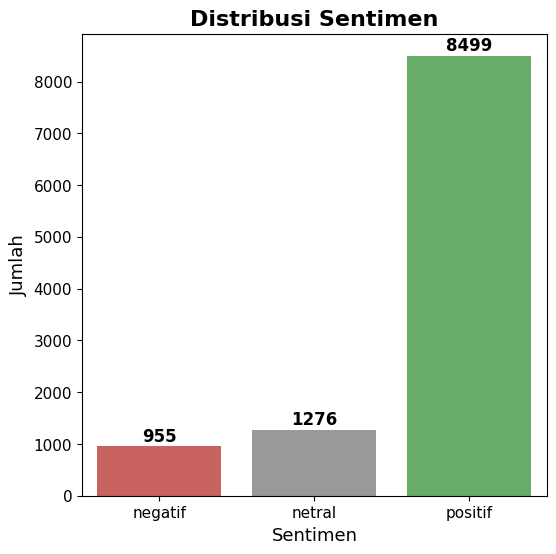

In [ ]:
# Bar Chart
plt.figure(figsize=(6, 6))
ax = sns.barplot(
    x=sentimen_counts.index,
    y=sentimen_counts.values,
    palette=color_map
)

plt.title('Distribusi Sentimen', fontsize=16, weight='bold')
plt.xlabel('Sentimen', fontsize=13)
plt.ylabel('Jumlah', fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Tambahkan label jumlah di atas setiap bar
for i, value in enumerate(sentimen_counts.values):
    plt.text(
        x=i,
        y=value + 20,  # agak di atas bar
        s=str(value),
        ha='center',
        va='bottom',
        color='black',
        fontsize=12,
        weight='bold'
    )


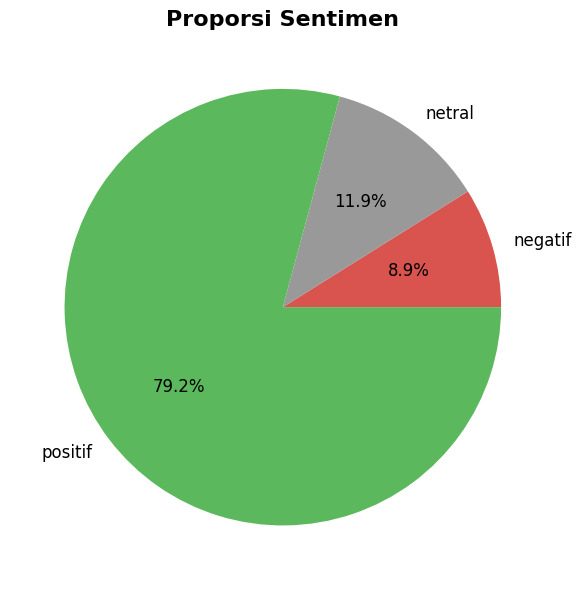

In [ ]:

plt.figure(figsize=(6, 6))
plt.pie(
    sentimen_counts.values,
    labels=sentimen_counts.index,
    autopct='%1.1f%%',
    colors=[color_map[s] for s in sentimen_counts.index],
    textprops={'color': 'black', 'fontsize': 12}
)
plt.title('Proporsi Sentimen', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

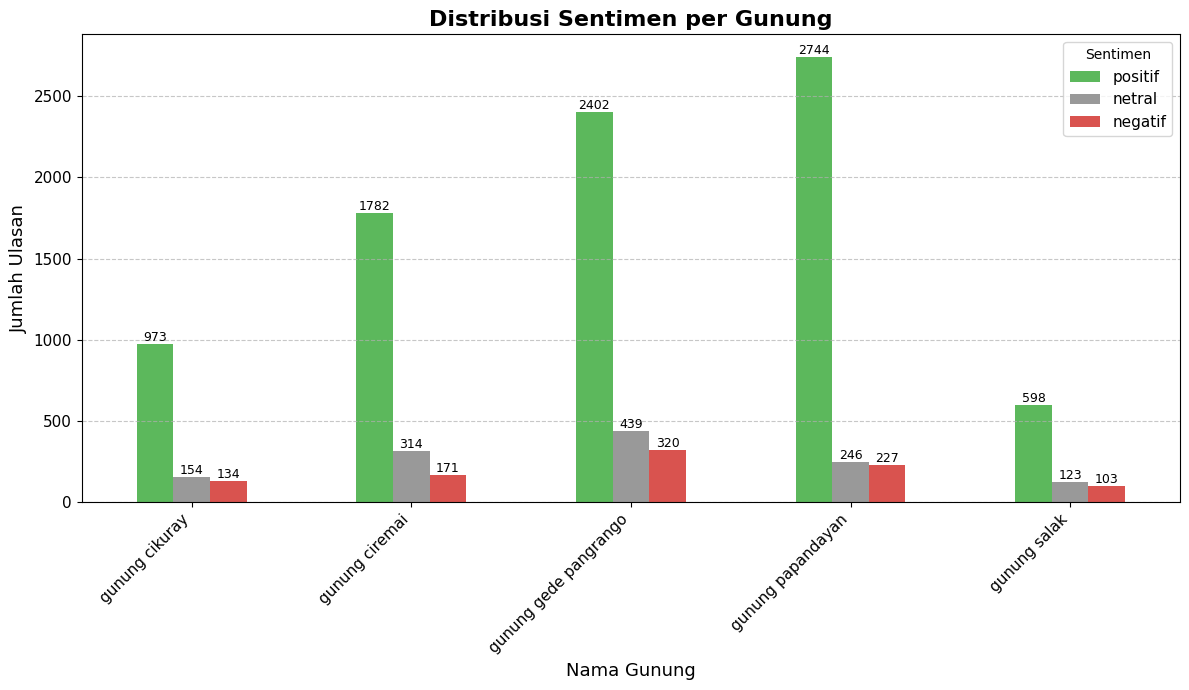

In [ ]:
# Menghitung jumlah ulasan per gunung dan label sentimen
sentiment_by_mountain = df_visual.groupby(['nama_gunung', 'sentimen_label']).size().unstack(fill_value=0)

# Mengurutkan kolom sentimen agar urutan di plot konsisten
sentiment_by_mountain = sentiment_by_mountain[['positif', 'netral', 'negatif']]

# Membuat stacked bar chart
ax = sentiment_by_mountain.plot(kind='bar', stacked=False, figsize=(12, 7), color=[color_map[col] for col in sentiment_by_mountain.columns])

plt.title('Distribusi Sentimen per Gunung', fontsize=16, weight='bold')
plt.xlabel('Nama Gunung', fontsize=13)
plt.ylabel('Jumlah Ulasan', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title='Sentimen', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7) # Tambahkan grid untuk memudahkan membaca nilai

# Menambahkan label jumlah di atas setiap bar (jika stacked=False)
# Jika stacked=True, logic penambahan label akan berbeda
# Untuk stacked=False, loop melalui setiap patch (bar) dan tambahkan label
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=9) # Menambahkan label di atas setiap bar

plt.tight_layout() # Menyesuaikan layout agar rapi
plt.show()

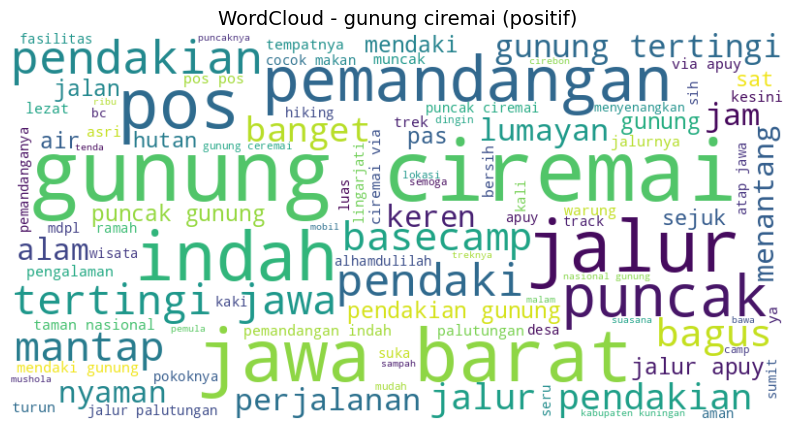

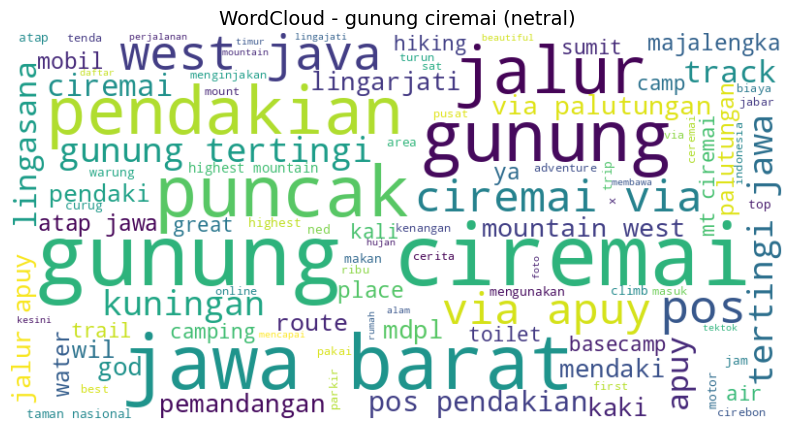

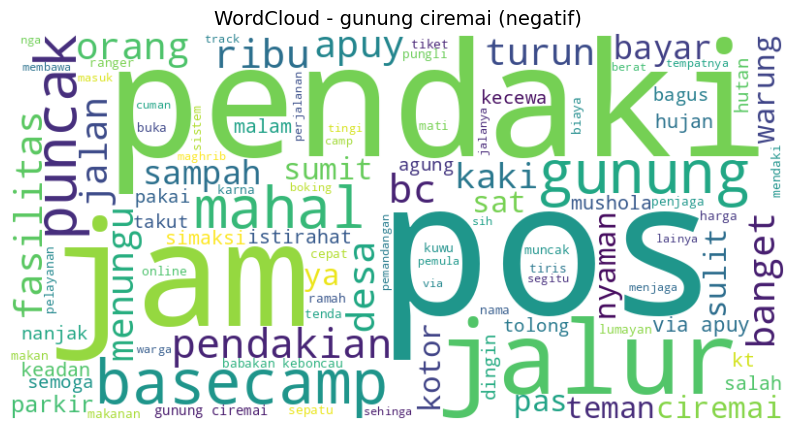

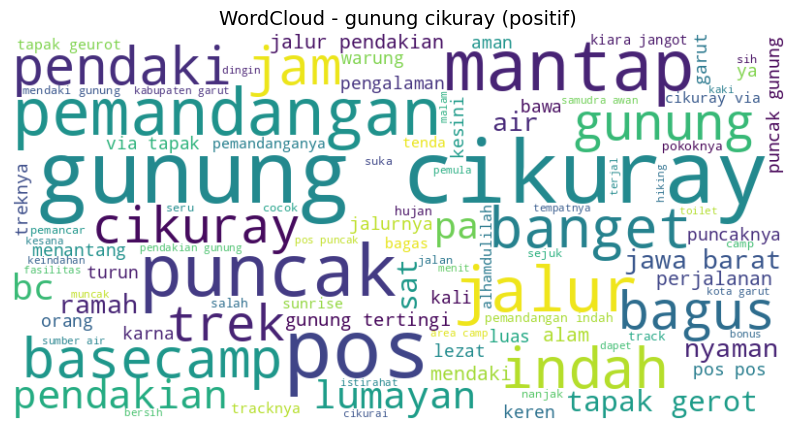

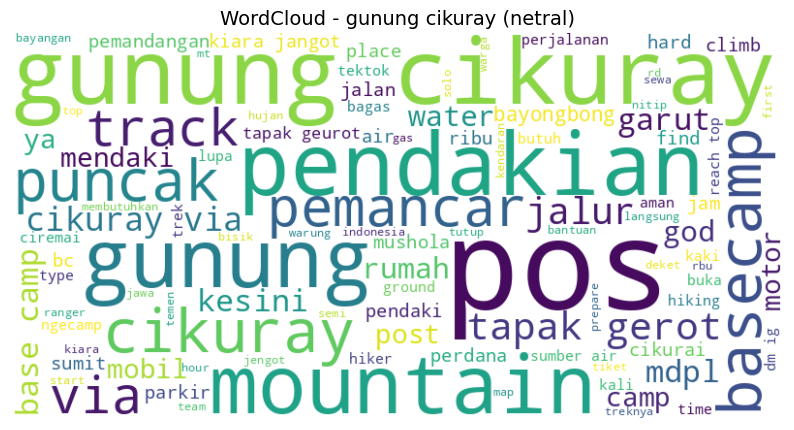

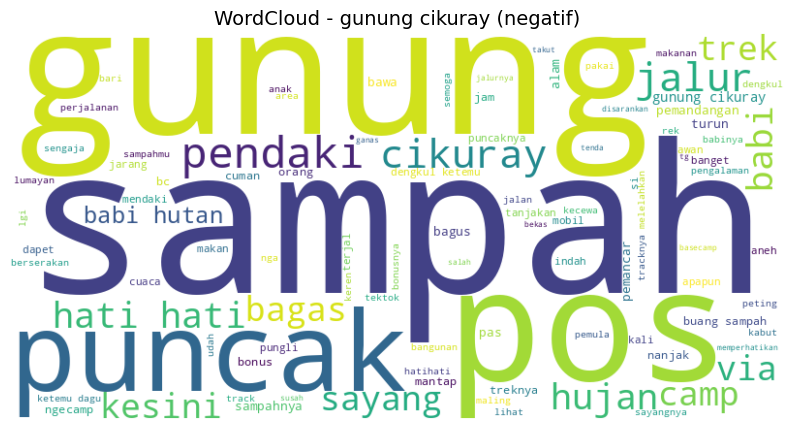

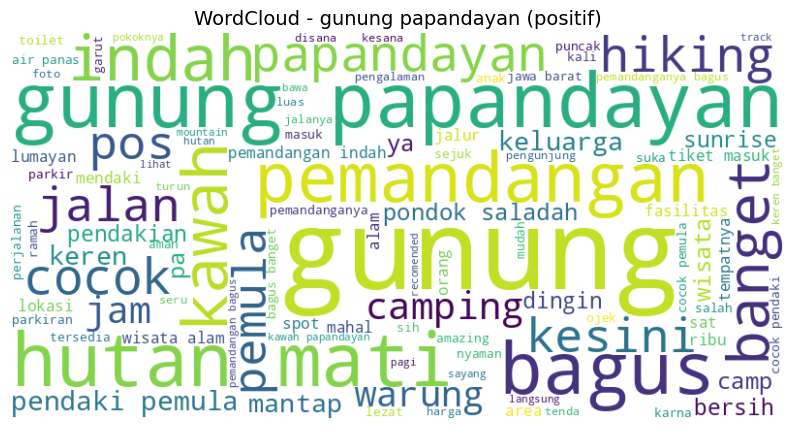

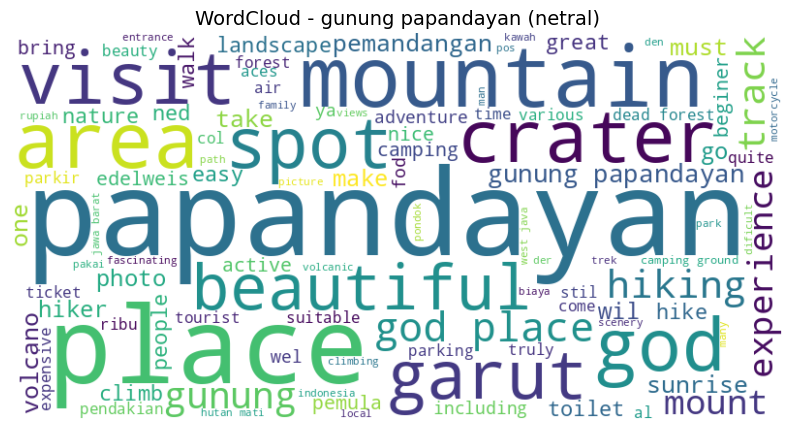

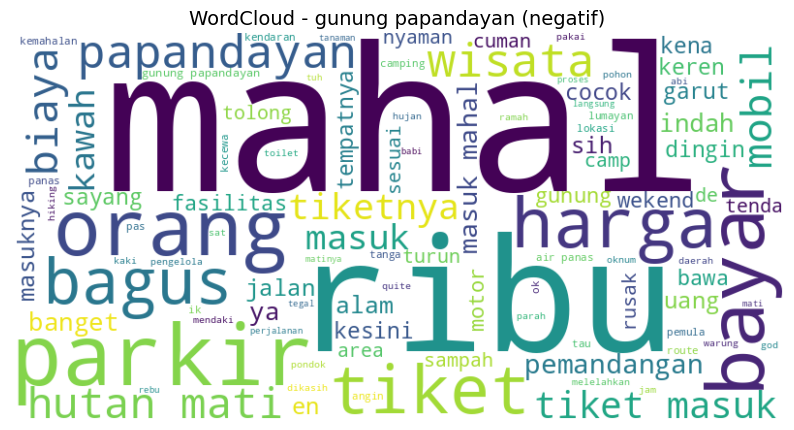

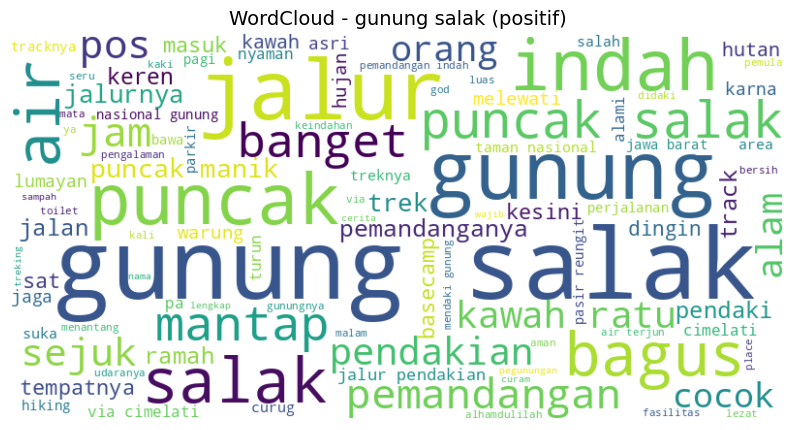

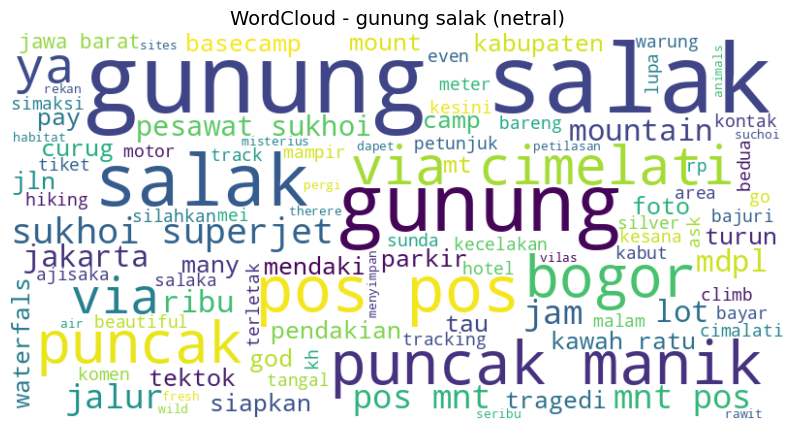

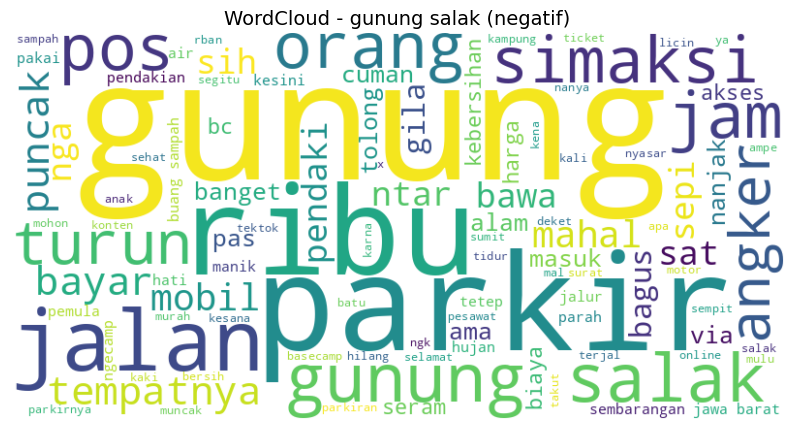

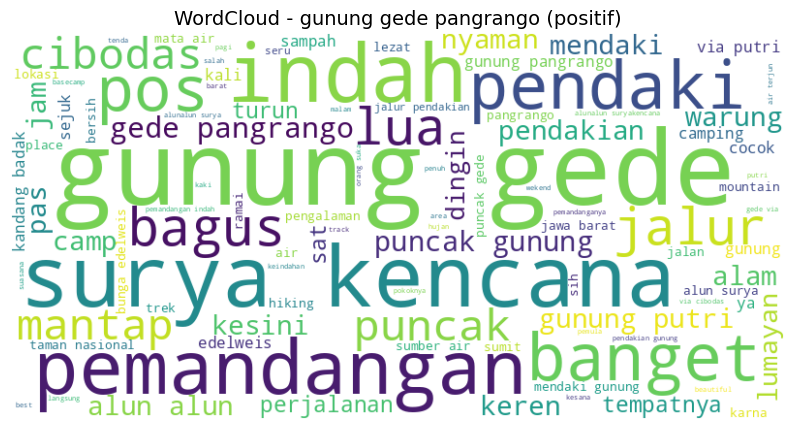

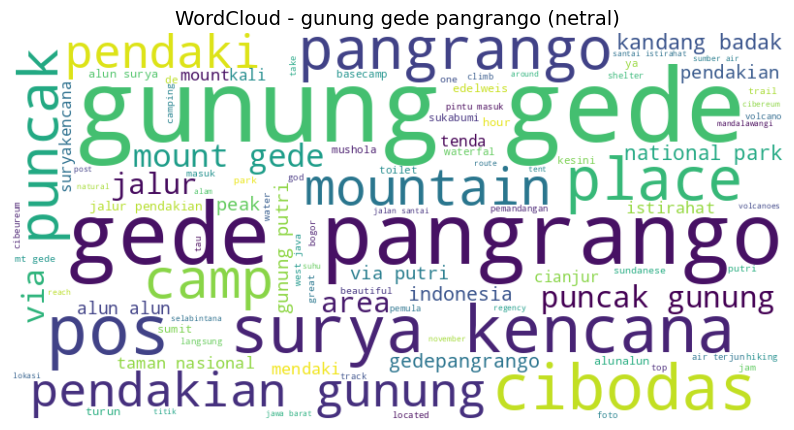

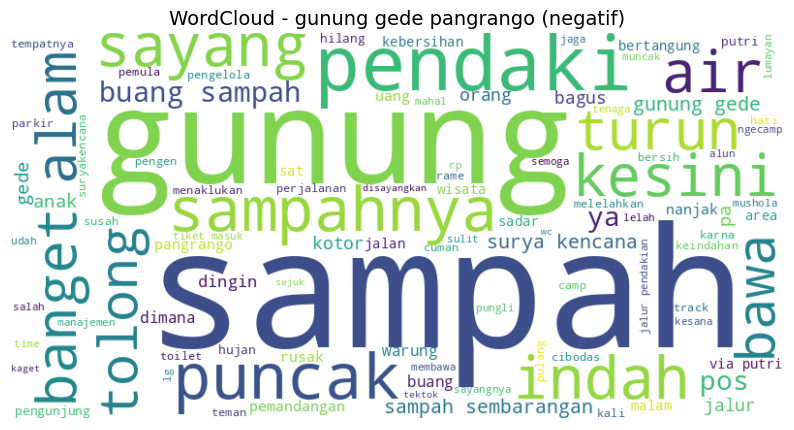

In [ ]:
# --- Set ukuran figure secara global ---
plt.rcParams['figure.figsize'] = (10, 6)

# --- Loop per gunung dan label sentimen ---
for gunung in df_visual['nama_gunung'].unique():
    for label in df_visual['sentimen_label'].unique():
        # Ambil data sesuai gunung dan label
        subset = df_visual[
            (df_visual['nama_gunung'] == gunung) &
            (df_visual['sentimen_label'] == label)
        ]

        # Jika tidak ada data untuk kombinasi ini, skip
        if subset.empty:
            continue

        # Gabungkan semua teks dalam 1 string
        text = ' '.join(subset['text_clean'].astype(str))

        # --- Buat WordCloud ---
        wc = WordCloud(
            width=800,
            height=400,
            background_color='white',
            colormap='viridis',
            max_words=100
        ).generate(text)

        # --- Tampilkan WordCloud ---
        plt.figure()
        plt.imshow(wc, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"WordCloud - {gunung} ({label})", fontsize=14)
        plt.show()

### *Topic Modeling (BERTopic)*

In [ ]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora.dictionary import Dictionary
import nltk
from nltk.tokenize import word_tokenize

In [ ]:
 nltk.download('punkt_tab')
 nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# Memuat data yang sudah diberi label sentimen untuk topic modeling
df_tm = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/data_labeled.csv')

In [ ]:
stop_id = set(stopwords.words('indonesian'))
stop_en = set(stopwords.words('english'))

custom_stop = ['hutan mati','surya kencana','gede','pangrango','ciremai',
               'cikuray','salak','papandayan']

# Gabungkan set dan list stop words dengan benar
stop_words = list(stop_id.union(stop_en).union(set(custom_stop)))

def remove_stopwords(text, stopword_set):
    # Convert input to string to handle potential non-string values (like floats/NaN)
    text = str(text)
    return ' '.join([word for word in text.split() if word not in stopword_set])

In [ ]:
df_tm['text_clean'] = df_tm['text'].astype(str).apply(lambda x: remove_stopwords(x, stop_words))


In [ ]:

df_positif = df_tm[df_tm['sentimen_label'] == 'positif']
df_netral = df_tm[df_tm['sentimen_label'] == 'netral']
df_negatif = df_tm[df_tm['sentimen_label'] == 'negatif']

In [ ]:
print("Jumlah komentar positif:", len(df_positif))
print("Jumlah komentar netral :", len(df_netral))
print("Jumlah komentar negatif:", len(df_negatif))

Jumlah komentar positif: 8499
Jumlah komentar netral : 1276
Jumlah komentar negatif: 955


In [ ]:
embedding_model = SentenceTransformer("distiluse-base-multilingual-cased-v2")

In [ ]:
# Komentar per sentimen
komentar_positif = df_positif['text_clean'].tolist()
komentar_netral  = df_netral['text_clean'].tolist()
komentar_negatif = df_negatif['text_clean'].tolist()

# BERTopic per kategori sentimen
model_positif = BERTopic(embedding_model=embedding_model, verbose=True)
topics_positif, probs_positif = model_positif.fit_transform(komentar_positif)

model_netral = BERTopic(embedding_model=embedding_model, verbose=True)
topics_netral, probs_netral = model_netral.fit_transform(komentar_netral)

model_negatif = BERTopic(embedding_model=embedding_model, verbose=True)
topics_negatif, probs_negatif = model_negatif.fit_transform(komentar_negatif)

2025-11-09 10:02:41,042 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/266 [00:00<?, ?it/s]

2025-11-09 10:10:09,547 - BERTopic - Embedding - Completed ✓
2025-11-09 10:10:09,548 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-09 10:10:26,915 - BERTopic - Dimensionality - Completed ✓
2025-11-09 10:10:26,917 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-09 10:10:27,284 - BERTopic - Cluster - Completed ✓
2025-11-09 10:10:27,292 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-09 10:10:27,575 - BERTopic - Representation - Completed ✓
2025-11-09 10:10:27,987 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/40 [00:00<?, ?it/s]

2025-11-09 10:11:08,719 - BERTopic - Embedding - Completed ✓
2025-11-09 10:11:08,721 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-09 10:11:12,935 - BERTopic - Dimensionality - Completed ✓
2025-11-09 10:11:12,936 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-09 10:11:12,980 - BERTopic - Cluster - Completed ✓
2025-11-09 10:11:12,985 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-09 10:11:13,039 - BERTopic - Representation - Completed ✓
2025-11-09 10:11:13,116 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/30 [00:00<?, ?it/s]

2025-11-09 10:11:53,134 - BERTopic - Embedding - Completed ✓
2025-11-09 10:11:53,135 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-11-09 10:11:55,855 - BERTopic - Dimensionality - Completed ✓
2025-11-09 10:11:55,856 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-11-09 10:11:55,889 - BERTopic - Cluster - Completed ✓
2025-11-09 10:11:55,893 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-11-09 10:11:55,943 - BERTopic - Representation - Completed ✓


In [ ]:
# Fungsi untuk menghitung coherence score dari hasil model BERTopic
def hitung_coherence_score(model, komentar):
    # Dapatkan daftar topik (top 10 kata per topik)
    topik_kata = model.get_topics()
    topik_kata_list = [[kata for kata, _ in topik_kata[i]] for i in topik_kata]

    # Preprocessing komentar
    tokenized_docs = [word_tokenize(doc.lower()) for doc in komentar]

    # Buat dictionary dan corpus dari data yang sudah di-tokenize
    dictionary = Dictionary(tokenized_docs)
    corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

    # Hitung coherence score pakai 'c_v' (bisa juga 'u_mass', 'c_uci', dll)
    coherence_model = CoherenceModel(
        topics=topik_kata_list,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return coherence_model.get_coherence()

In [ ]:
# Hitung coherence score per model
coherence_positif = hitung_coherence_score(model_positif, komentar_positif)
coherence_netral  = hitung_coherence_score(model_netral, komentar_netral)
coherence_negatif = hitung_coherence_score(model_negatif, komentar_negatif)

# Tampilkan hasilnya
print("Coherence Score Positif:", coherence_positif)
print("Coherence Score Netral :", coherence_netral)
print("Coherence Score Negatif:", coherence_negatif)

Coherence Score Positif: 0.3864428120930274
Coherence Score Netral : 0.41574243091355384
Coherence Score Negatif: 0.46146557989429277


In [ ]:
print("Topik Positif:")
model_positif.get_topic_info().head()

Topik Positif:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,2597,-1_camping_camp_pemandangan_gunung,"[camping, camp, pemandangan, gunung, warung, p...",[pemandangan alam bagus gunung cocok pendaki p...
1,0,332,0_mantap_seru_kangen_treknya,"[mantap, seru, kangen, treknya, rindu, penat, ...","[treknya mantap, mantap treknya, mantap banget]"
2,1,248,1_gunung_indah_mountain_pemandangan,"[gunung, indah, mountain, pemandangan, keindah...","[gunung pemandangan bagus indah, pemandangan g..."
3,2,208,2_gunung_yok_keturutan_mantap,"[gunung, yok, keturutan, mantap, umat, terting...","[yok yok puji tuhan keturutan mendaki gunung, ..."
4,3,124,3_indah_cantik_keindahan_indahnya,"[indah, cantik, keindahan, indahnya, hakiki, b...","[indah banget, indah banget, indah indah]"


In [ ]:
print("Topik netral:")
model_netral.get_topic_info().head()

Topik netral:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,440,-1_gunung_pos_puncak_jalur,"[gunung, pos, puncak, jalur, via, mountain, pe...",[gunung gunung api bertipe stratovolcano pulau...
1,0,67,0_mt_mdpl_semi_trek,"[mt, mdpl, semi, trek, semoga, teman, sept, si...","[kh hu khng qu lnh mt, mt mdpl, mt mdpl]"
2,1,62,1_zaky_curug_bisik_raga,"[zaky, curug, bisik, raga, mantul, hati, warga...","[olah raga jiwa raga, curug limbangan curug lo..."
3,2,54,2_place_god_visit_must,"[place, god, visit, must, suitable, spot, fami...","[god place god track, god place god mountain, ..."
4,3,46,3_gunung_pendakian_mendaki_via,"[gunung, pendakian, mendaki, via, palutungan, ...",[bisan mendaki gunung jalur palutungan lingarj...


In [ ]:
print("Topik negatif:")
model_negatif.get_topic_info().head()

Topik negatif:


,Topic,Count,Name,Representation,Representative_Docs
0,-1,299,-1_pos_fasilitas_jam_sampah,"[pos, fasilitas, jam, sampah, pendakian, alam,...",[gunung tertingi jawa barat pos pendakian pos ...
1,0,67,0_sampah_gunung_pendaki_pos,"[sampah, gunung, pendaki, pos, desa, puncak, a...",[april jalanya nanjak tanah hujan licin banget...
2,1,53,1_ribu_parkir_mobil_masuk,"[ribu, parkir, mobil, masuk, orang, tiket, bay...",[tiket masuk ribu tiket kendaran ribu parkir r...
3,2,52,2_gunung_menaklukan_angker_meletus,"[gunung, menaklukan, angker, meletus, seram, m...",[menaklukan gunung menaklukan gunung fiersa be...
4,3,47,3_lope_ce_wes_belerang,"[lope, ce, wes, belerang, diam, enga, capek, n...","[lope lope lope udah, pulsa ce mimih yng amina..."


In [ ]:
model_positif.get_topic_info().to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_positif.csv', index=False)
model_netral.get_topic_info().to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_netral.csv', index=False)
model_negatif.get_topic_info().to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_negatif.csv', index=False)

*Pelabelan Topik*

In [5]:
topik_positif = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_positif.csv')
topik_positif

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2597,-1_camping_camp_pemandangan_gunung,"['camping', 'camp', 'pemandangan', 'gunung', '...",['pemandangan alam bagus gunung cocok pendaki ...
1,0,332,0_mantap_seru_kangen_treknya,"['mantap', 'seru', 'kangen', 'treknya', 'rindu...","['treknya mantap', 'mantap treknya', 'mantap b..."
2,1,248,1_gunung_indah_mountain_pemandangan,"['gunung', 'indah', 'mountain', 'pemandangan',...","['gunung pemandangan bagus indah', 'pemandanga..."
3,2,208,2_gunung_yok_keturutan_mantap,"['gunung', 'yok', 'keturutan', 'mantap', 'umat...",['yok yok puji tuhan keturutan mendaki gunung'...
4,3,124,3_indah_cantik_keindahan_indahnya,"['indah', 'cantik', 'keindahan', 'indahnya', '...","['indah banget', 'indah banget', 'indah indah']"
...,...,...,...,...,...
157,156,11,156_lingkungan_lingkunganya_memperhatikan_menjaga,"['lingkungan', 'lingkunganya', 'memperhatikan'...",['jagalah flora fauna lingkunganya pengunjung ...
158,157,11,157_dramatic_trakingnya_lubang_distances,"['dramatic', 'trakingnya', 'lubang', 'distance...",['gunung indah garut pos menampilkan pemandang...
159,158,10,158_healing_kebersamanya_kebugaran_udinya,"['healing', 'kebersamanya', 'kebugaran', 'udin...","['suasana keren pas healing', 'bagus healing',..."
160,159,10,159_putri_lintas_via_cibodas,"['putri', 'lintas', 'via', 'cibodas', 'gbisa',...",['kemaren putri lintas cibodas pemandanganya k...


In [6]:
topik_penting = [0, 1, 10, 13, 17]

# Filter hanya baris dengan topik tersebut
topikpos_terpilih = topik_positif[topik_positif['Topic'].isin(topik_penting)]

# Tampilkan hasilnya
display(topikpos_terpilih)

,Topic,Count,Name,Representation,Representative_Docs
1,0,332,0_mantap_seru_kangen_treknya,"['mantap', 'seru', 'kangen', 'treknya', 'rindu...","['treknya mantap', 'mantap treknya', 'mantap b..."
2,1,248,1_gunung_indah_mountain_pemandangan,"['gunung', 'indah', 'mountain', 'pemandangan',...","['gunung pemandangan bagus indah', 'pemandanga..."
11,10,74,10_bagus_banget_masyalah_fasilitasnya,"['bagus', 'banget', 'masyalah', 'fasilitasnya'...","['bagus jalur bagus', 'bagus banget', 'bagus b..."
14,13,68,13_sejuk_dingin_hawanya_rindang,"['sejuk', 'dingin', 'hawanya', 'rindang', 'asi...","['sejuk asri banget', 'dingin dingin seru', 'l..."
18,17,63,17_foto_spot_photo_instagramable,"['foto', 'spot', 'photo', 'instagramable', 'pr...","['bagus foto', 'spot foto bagus', 'spot foto b..."


In [7]:
# Mapping topik ID ke nama baru
topik_rename_map = {
    0: "Trek Perjalanannya Seru",
    1: "Pemandangannya Indah",
    10: "Fasilitasnya Bagus",
    13: "Hawanya sejuk",
    17: "Spot Foto Bagus"
}

# Ganti nama topik berdasarkan mapping
topikpos_terpilih['Name'] = topikpos_terpilih.apply(
    lambda row: topik_rename_map.get(row['Topic'], row['Name']),
    axis=1
)

# Tampilkan
display(topikpos_terpilih)

/tmp/ipython-input-2173720788.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topikpos_terpilih['Name'] = topikpos_terpilih.apply(


,Topic,Count,Name,Representation,Representative_Docs
1,0,332,Trek Perjalanannya Seru,"['mantap', 'seru', 'kangen', 'treknya', 'rindu...","['treknya mantap', 'mantap treknya', 'mantap b..."
2,1,248,Pemandangannya Indah,"['gunung', 'indah', 'mountain', 'pemandangan',...","['gunung pemandangan bagus indah', 'pemandanga..."
11,10,74,Fasilitasnya Bagus,"['bagus', 'banget', 'masyalah', 'fasilitasnya'...","['bagus jalur bagus', 'bagus banget', 'bagus b..."
14,13,68,Hawanya sejuk,"['sejuk', 'dingin', 'hawanya', 'rindang', 'asi...","['sejuk asri banget', 'dingin dingin seru', 'l..."
18,17,63,Spot Foto Bagus,"['foto', 'spot', 'photo', 'instagramable', 'pr...","['bagus foto', 'spot foto bagus', 'spot foto b..."


In [8]:
topikpos_terpilih.to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_positif_label.csv', index=False)

In [9]:
topik_negatif = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_negatif.csv')
topik_negatif

,Topic,Count,Name,Representation,Representative_Docs
0,-1,299,-1_pos_fasilitas_jam_sampah,"['pos', 'fasilitas', 'jam', 'sampah', 'pendaki...",['gunung tertingi jawa barat pos pendakian pos...
1,0,67,0_sampah_gunung_pendaki_pos,"['sampah', 'gunung', 'pendaki', 'pos', 'desa',...",['april jalanya nanjak tanah hujan licin bange...
2,1,53,1_ribu_parkir_mobil_masuk,"['ribu', 'parkir', 'mobil', 'masuk', 'orang', ...",['tiket masuk ribu tiket kendaran ribu parkir ...
3,2,52,2_gunung_menaklukan_angker_meletus,"['gunung', 'menaklukan', 'angker', 'meletus', ...",['menaklukan gunung menaklukan gunung fiersa b...
4,3,47,3_lope_ce_wes_belerang,"['lope', 'ce', 'wes', 'belerang', 'diam', 'eng...","['lope lope lope udah', 'pulsa ce mimih yng am..."
5,4,41,4_merah_ter_pemula_burikbacot,"['merah', 'ter', 'pemula', 'burikbacot', 'abse...","['bt pemula', 'ter ter ter', 'merah merah merah']"
6,5,34,5_tiket_tiketnya_mahal_harga,"['tiket', 'tiketnya', 'mahal', 'harga', 'masuk...","['tiketnya mahal', 'mahal tiketnya', 'tiket ma..."
7,6,31,6_sampah_sampahnya_berserakan_dimana,"['sampah', 'sampahnya', 'berserakan', 'dimana'...",['spt diatas awantpi syg sampah berserakan dim...
8,7,29,7_mdpl_ketingian_dng_alamat,"['mdpl', 'ketingian', 'dng', 'alamat', 'kebera...","['capek mdpl', 'ketingian mdpl', 'ketingian md..."
9,8,27,8_hutan_mati_matinya_tanaman,"['hutan', 'mati', 'matinya', 'tanaman', 'area'...","['hutan mati melelahkan', 'hutan mati gunung',..."


In [10]:
# Misal kamu hanya ingin ambil topik 1, 2, dan 4
topik_penting = [0, 1, 2, 5]

# Filter hanya baris dengan topik tersebut
topikneg_terpilih = topik_negatif[topik_negatif['Topic'].isin(topik_penting)]

# Tampilkan hasilnya
display(topikneg_terpilih)

,Topic,Count,Name,Representation,Representative_Docs
1,0,67,0_sampah_gunung_pendaki_pos,"['sampah', 'gunung', 'pendaki', 'pos', 'desa',...",['april jalanya nanjak tanah hujan licin bange...
2,1,53,1_ribu_parkir_mobil_masuk,"['ribu', 'parkir', 'mobil', 'masuk', 'orang', ...",['tiket masuk ribu tiket kendaran ribu parkir ...
3,2,52,2_gunung_menaklukan_angker_meletus,"['gunung', 'menaklukan', 'angker', 'meletus', ...",['menaklukan gunung menaklukan gunung fiersa b...
6,5,34,5_tiket_tiketnya_mahal_harga,"['tiket', 'tiketnya', 'mahal', 'harga', 'masuk...","['tiketnya mahal', 'mahal tiketnya', 'tiket ma..."


In [11]:
# Mapping topik ID ke nama baru
topik_rename_map = {
    0: "Sampah di Gunung",
    1: "Biaya Parkir Mahal",
    2: "Gunung Angker",
    5: "Tiket Mahal",
}

# Ganti nama topik berdasarkan mapping
topikneg_terpilih['Name'] = topikneg_terpilih.apply(
    lambda row: topik_rename_map.get(row['Topic'], row['Name']),
    axis=1
)

# Tampilkan
display(topikneg_terpilih)

/tmp/ipython-input-2629013770.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topikneg_terpilih['Name'] = topikneg_terpilih.apply(


,Topic,Count,Name,Representation,Representative_Docs
1,0,67,Sampah di Gunung,"['sampah', 'gunung', 'pendaki', 'pos', 'desa',...",['april jalanya nanjak tanah hujan licin bange...
2,1,53,Biaya Parkir Mahal,"['ribu', 'parkir', 'mobil', 'masuk', 'orang', ...",['tiket masuk ribu tiket kendaran ribu parkir ...
3,2,52,Gunung Angker,"['gunung', 'menaklukan', 'angker', 'meletus', ...",['menaklukan gunung menaklukan gunung fiersa b...
6,5,34,Tiket Mahal,"['tiket', 'tiketnya', 'mahal', 'harga', 'masuk...","['tiketnya mahal', 'mahal tiketnya', 'tiket ma..."


In [12]:
topikneg_terpilih.to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_negatif_label.csv', index=False)

In [13]:
topik_netral = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_netral.csv')
topik_netral

,Topic,Count,Name,Representation,Representative_Docs
0,-1,440,-1_gunung_pos_puncak_jalur,"['gunung', 'pos', 'puncak', 'jalur', 'via', 'm...",['gunung gunung api bertipe stratovolcano pula...
1,0,67,0_mt_mdpl_semi_trek,"['mt', 'mdpl', 'semi', 'trek', 'semoga', 'tema...","['kh hu khng qu lnh mt', 'mt mdpl', 'mt mdpl']"
2,1,62,1_zaky_curug_bisik_raga,"['zaky', 'curug', 'bisik', 'raga', 'mantul', '...","['olah raga jiwa raga', 'curug limbangan curug..."
3,2,54,2_place_god_visit_must,"['place', 'god', 'visit', 'must', 'suitable', ...","['god place god track', 'god place god mountai..."
4,3,46,3_gunung_pendakian_mendaki_via,"['gunung', 'pendakian', 'mendaki', 'via', 'pal...",['bisan mendaki gunung jalur palutungan lingar...
5,4,44,4_gunung_bogor_menyimpan_kaki,"['gunung', 'bogor', 'menyimpan', 'kaki', 'mdpl...","['kaki gunung', 'kaki gunung', 'gunung bogor']"
6,5,43,5_camping_camp_kandang_basecamp,"['camping', 'camp', 'kandang', 'basecamp', 'gr...",['awesome mountain last time im visiting mount...
7,6,42,6_surya_kencana_alun_sunrise,"['surya', 'kencana', 'alun', 'sunrise', 'pagi'...","['alun alun surya kencana pos puncak', 'alun s..."
8,7,41,7_camp_basecamp_ground_camping,"['camp', 'basecamp', 'ground', 'camping', 'sum...","['pos jalur tapak geurot camping ground', 'cam..."
9,8,40,8_mount_park_national_natural,"['mount', 'park', 'national', 'natural', 'arou...",['mount located west java active stratovolcano...


In [14]:
# Misal kamu hanya ingin ambil topik 1, 2, dan 4
topik_penting = [-1]

# Filter hanya baris dengan topik tersebut
topiknet_terpilih = topik_netral[topik_netral['Topic'].isin(topik_penting)]

# Tampilkan hasilnya
display(topiknet_terpilih)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,440,-1_gunung_pos_puncak_jalur,"['gunung', 'pos', 'puncak', 'jalur', 'via', 'm...",['gunung gunung api bertipe stratovolcano pula...


In [15]:
# Mapping topik ID ke nama baru
topik_rename_map = {
    -1 : "Mixed"
}

# Ganti nama topik berdasarkan mapping
topiknet_terpilih['Name'] = topiknet_terpilih.apply(
    lambda row: topik_rename_map.get(row['Topic'], row['Name']),
    axis=1
)

# Tampilkan
display(topiknet_terpilih)

/tmp/ipython-input-2137406229.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  topiknet_terpilih['Name'] = topiknet_terpilih.apply(


,Topic,Count,Name,Representation,Representative_Docs
0,-1,440,Mixed,"['gunung', 'pos', 'puncak', 'jalur', 'via', 'm...",['gunung gunung api bertipe stratovolcano pula...


In [16]:
topiknet_terpilih.to_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_netral_label.csv', index=False)

### Visualisasi Topik Modeling

In [17]:
topik_positif = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_positif_label.csv')
topik_negatif = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_negatif_label.csv')
topik_netral = pd.read_csv('/content/drive/MyDrive/Projek/dummy/gunung_jabar/processed/topik_netral_label.csv')

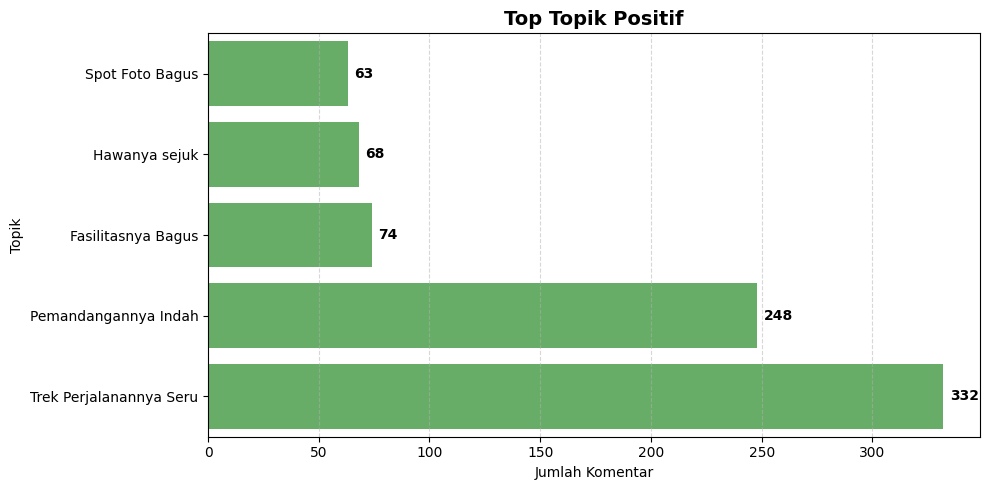

In [19]:
# Urutkan dari kecil ke besar (agar bar horizontal rapi)
df_sorted = topik_positif.sort_values("Count", ascending=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x="Count", y="Name", data=df_sorted, color="#5cb85c")

# Judul dan label
plt.title("Top Topik Positif", fontsize=14, weight='bold')
plt.xlabel("Jumlah Komentar")
plt.ylabel("Topik")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Tambahkan angka jumlah di ujung setiap bar
for i, value in enumerate(df_sorted["Count"]):
    plt.text(
        x=value + 3,  # beri jarak dari ujung bar
        y=i,          # posisi y = indeks bar
        s=str(value),
        va='center',
        fontsize=10,
        color='black',
        weight='bold'
    )

plt.tight_layout()
plt.show()

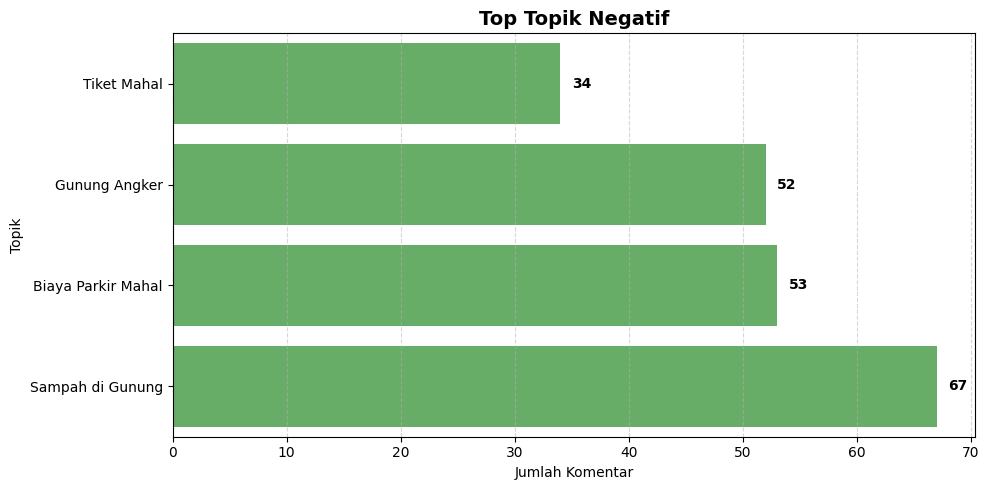

In [22]:
# Urutkan dari kecil ke besar (agar bar horizontal rapi)
df_sorted = topik_negatif.sort_values("Count", ascending=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x="Count", y="Name", data=df_sorted, color="#5cb85c")

# Judul dan label
plt.title("Top Topik Negatif", fontsize=14, weight='bold')
plt.xlabel("Jumlah Komentar")
plt.ylabel("Topik")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Tambahkan angka jumlah di ujung setiap bar
for i, value in enumerate(df_sorted["Count"]):
    plt.text(
        x=value + 1,  # beri jarak dari ujung bar
        y=i,          # posisi y = indeks bar
        s=str(value),
        va='center',
        fontsize=10,
        color='black',
        weight='bold'
    )

plt.tight_layout()
plt.show()

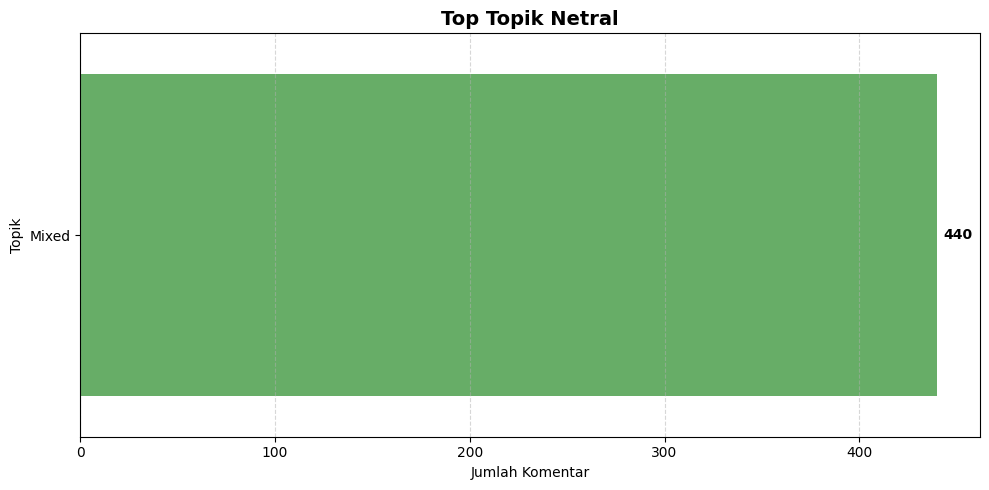

In [23]:
# Urutkan dari kecil ke besar (agar bar horizontal rapi)
df_sorted = topik_netral.sort_values("Count", ascending=True)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x="Count", y="Name", data=df_sorted, color="#5cb85c")

# Judul dan label
plt.title("Top Topik Netral", fontsize=14, weight='bold')
plt.xlabel("Jumlah Komentar")
plt.ylabel("Topik")
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Tambahkan angka jumlah di ujung setiap bar
for i, value in enumerate(df_sorted["Count"]):
    plt.text(
        x=value + 3,  # beri jarak dari ujung bar
        y=i,          # posisi y = indeks bar
        s=str(value),
        va='center',
        fontsize=10,
        color='black',
        weight='bold'
    )

plt.tight_layout()
plt.show()